In [1]:
import pandas as pd
from ggsc.annot import annotate_cell_cycle
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import numpy as np
from scipy.stats import spearmanr
from hcrseq.scRNA.analysis import get_repair_df
import matplotlib.patches as mpatches

In [2]:
def annotate_cell_cycle(adata):
    cell_cycle_genes = np.unique(pd.read_csv('gs://ibm-cart-0/reference/regev_lab_cell_cycle_genes.txt',
                                                         header=None)[0])
    s_genes = cell_cycle_genes[:43]
    g2m_genes = cell_cycle_genes[43:]
                    
    cell_cycle_genes = [x for x in cell_cycle_genes if x in adata.var_names]

                            
    adata_cc = adata.copy()
    sc.pp.scale(adata_cc)

    sc.tl.score_genes_cell_cycle(adata_cc, s_genes=s_genes, g2m_genes=g2m_genes)

    adata.obs=adata_cc.obs
                                                
    return(adata)

In [3]:
adata = sc.read('../data/P3_clustered.v0.h5ad')

## Figure 5a - U-Map of cell line clustering

In [4]:
adata.obs['label'] = adata.obs['cell_line'].replace({'TK6_ATCC' : 'TK6 LIG4-/-','HELA' : 'HELA XPA-/-','U2OS' : 'U2OS OGG-/-','HAP1' : 'HAP1 MUTYH-/-'})
adata.obs['label_newline'] = adata.obs['label'].str.replace(' ','\n')

/tmp/ipykernel_403457/2065127511.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['label'] = adata.obs['cell_line'].replace({'TK6_ATCC' : 'TK6 LIG4-/-','HELA' : 'HELA XPA-/-','U2OS' : 'U2OS OGG-/-','HAP1' : 'HAP1 MUTYH-/-'})


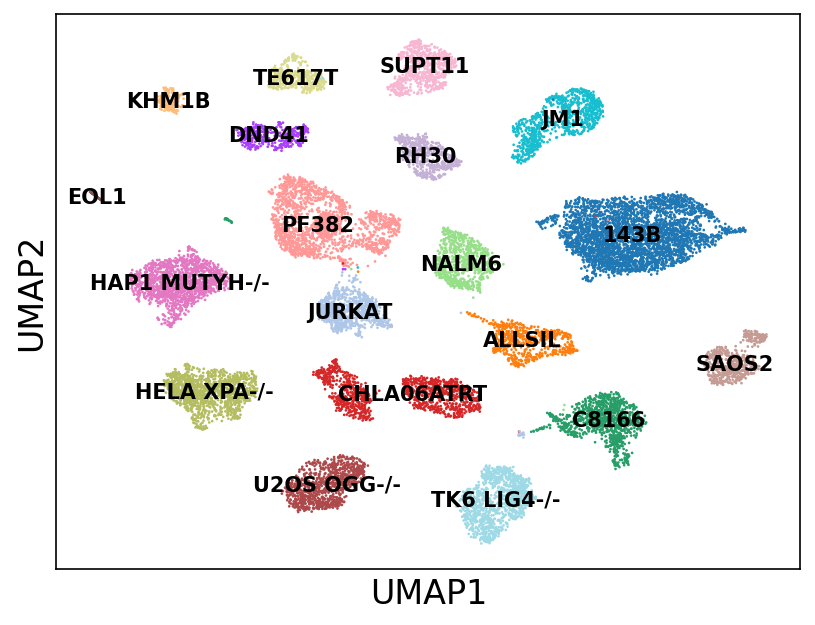

In [5]:
sc.pl.umap(adata,color='label',legend_loc='on data',show=False)
plt.title('')
plt.savefig('pdf/figure5a_scrna_umap_plot.pdf')

## Figure 5b - KO repair violins

/home/njharlen/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_utils.py:482: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/njharlen/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_utils.py:482: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/njharlen/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_utils.py:482: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/njharlen/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_utils.py:482: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


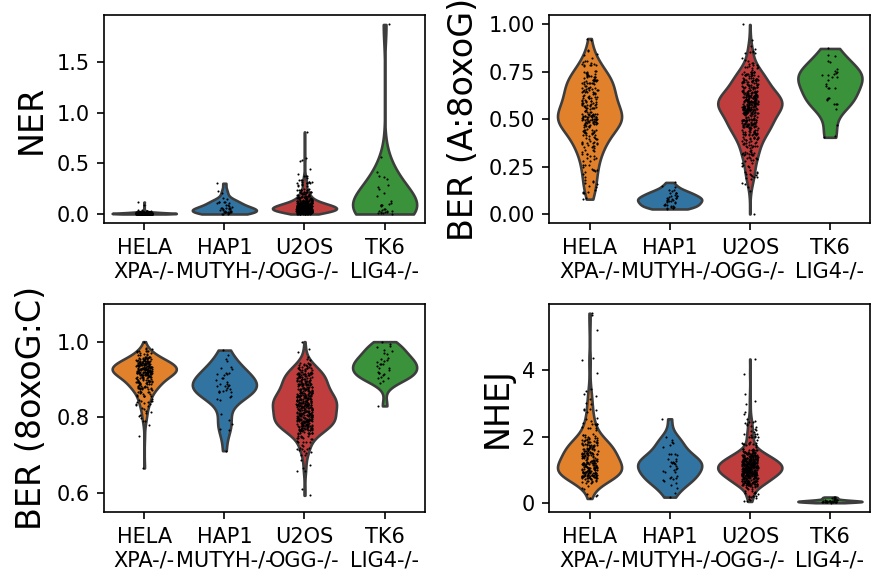

In [6]:
from scipy.stats import ranksums

idx = adata.obs['label'].str.contains('-/-')&adata.obs['transfected']&(adata.obs['timepoint']=='2h')

f,ax = plt.subplots(2,2,figsize=(6,4))
ax = ax.reshape(-1)

pathway_map = {'NER' : 'NER',
                'BER_A_8oxoG' : 'BER (A:8oxoG)',
                'BER_8oxoG_C' : 'BER (8oxoG:C)',
                'NHEJ' : 'NHEJ'}

controls = {'NER' : 'HELA',
                'BER_A_8oxoG' : 'HAP1',
                'BER_8oxoG_C' : 'U2OS',
                'NHEJ' : 'TK6_ATCC'}

cat_order = ['HELA\nXPA-/-', 'HAP1\nMUTYH-/-','U2OS\nOGG-/-', 'TK6\nLIG4-/-']

i=0
for pathway in pathway_map.keys():
    sc.pl.violin(adata[idx],pathway,
             groupby='label_newline',
             show=False,ax=ax[i],order=cat_order)

    # Compute p-value
    idx1 = idx & (adata.obs['cell_line']==controls[pathway])
    idx2 = idx & (adata.obs['cell_line']!=controls[pathway])
    stat,p = ranksums(adata.obs.loc[idx1,pathway],adata.obs.loc[idx2,pathway])
    
    
    ax[i].set_ylabel(pathway_map[pathway])
    ax[i].set_xlabel('')
    i+=1


ax[2].set_ylim([.55,1.1])

plt.tight_layout()


plt.savefig('pdf/figure5b_scrna_ko_lines.pdf',bbox_inches='tight')

In [7]:
from statsmodels.stats.multitest import multipletests

res = list()
for pathway in pathway_map.keys():

    # Compute p-value
    idx1 = idx & (adata.obs['cell_line']==controls[pathway])
    idx2 = idx & (adata.obs['cell_line']!=controls[pathway])
    stat,p = ranksums(adata.obs.loc[idx1,pathway],adata.obs.loc[idx2,pathway])

    res.append(pd.Series({'pathway' : pathway,'p' : p}))
P = pd.concat(res,axis=1).T.set_index('pathway')
P['q'] = multipletests(P['p'],method='fdr_bh')[1]
P

,p,q
pathway,,
NER,0.0,0.0
BER_A_8oxoG,0.0,0.0
BER_8oxoG_C,0.0,0.0
NHEJ,0.0,0.0


In [8]:
P['q'].values

array([np.float64(7.5939138359828756e-90),
       np.float64(5.508034588092915e-26),
       np.float64(1.1554390627643444e-60),
       np.float64(5.510853553068106e-21)], dtype=object)

## Figure 5c - heatmap of repair across WT cell lines

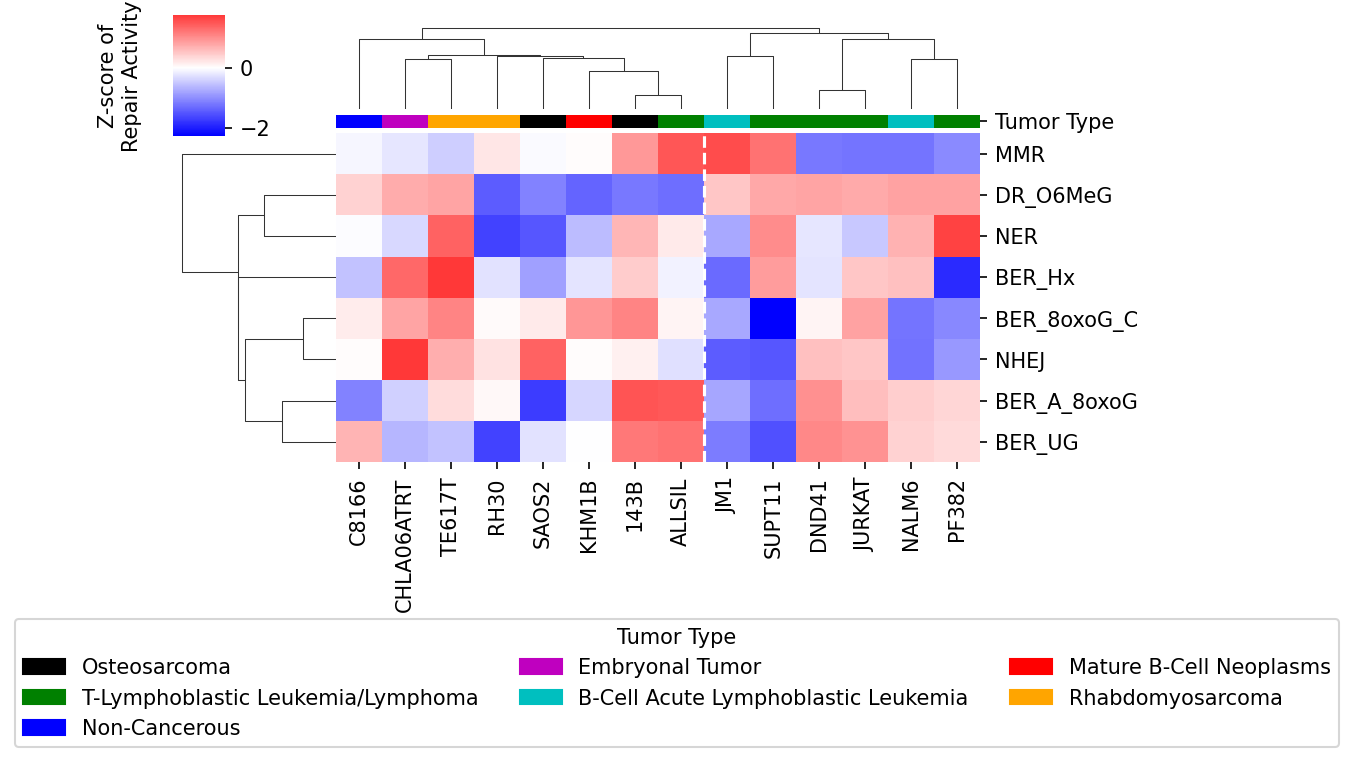

In [9]:
# Gather repair data
idx = ~adata.obs['cell_line'].isin(['HAP1','HELA','TK6_ATCC','U2OS'])

df = get_repair_df(adata[idx],groupby=['cell_line','timepoint'])
df = df[df['timepoint']=='2h']
df = df[df['n']>10]

X = df.set_index(['cell_line','pathway'])['repair'].unstack()

# Create color mapping

adata.uns['cell_line_info']['Tumor Type'] = adata.uns['cell_line_info']['OncotreePrimaryDisease']
key = 'Tumor Type'
value_map = adata.uns['cell_line_info'].loc[X.index][key]
unique_values = value_map.unique()
colors = list("kgbmcr") + ["orange"]
lut = dict(zip(unique_values, colors))
col_colors = value_map.map(lut)

# Create the clustermap
g = sns.clustermap(X.T, z_score=0, cmap='bwr', center=0, 
                   col_colors=col_colors, metric='correlation', method='single',figsize=(7,4.5))

# Add legend
legend_handles = [mpatches.Patch(color=c, label=l) for l, c in lut.items()]
g.fig.legend(handles=legend_handles, 
             title=key, 
             loc='upper center',         # The point of the legend box to align
             bbox_to_anchor=(0.5, 0.1),  # 0.5 is horizontal center, 0.05 is near the bottom
             ncol=3,                     # Organizes labels into columns to save vertical space
             bbox_transform=g.fig.transFigure)

# Adjust labels
g.ax_cbar.set_ylabel('Z-score of\nRepair Activity', fontsize=10)
g.ax_cbar.yaxis.set_label_position('left')
g.ax_cbar.yaxis.labelpad = 15
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.set_xlabel('')

g.ax_heatmap.axvline(8,linestyle='--',color='w')

plt.savefig('pdf/figure5c_scrna_repair_heatmap.pdf',bbox_inches='tight')

## Figure 5d - MGMT vs O6MeG repair

/tmp/ipykernel_403457/1193664357.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata[idx,'MGMT'].to_df().join(adata.obs[idx]).groupby('cell_line')[['MGMT','DR_O6MeG','MMR']].mean()


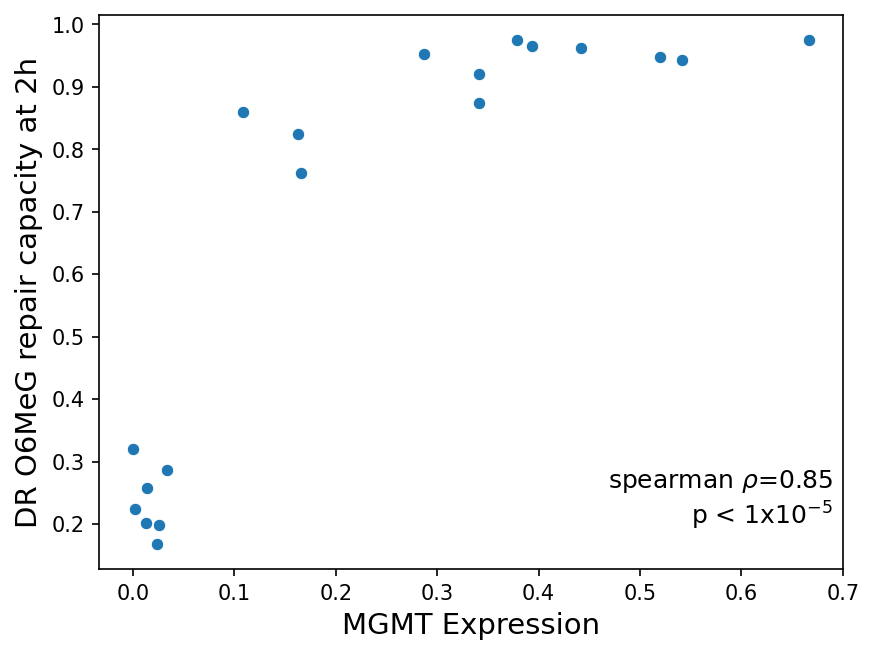

In [10]:
idx = adata.obs['transfected']&(adata.obs['timepoint']=='2h')

df = adata[idx,'MGMT'].to_df().join(adata.obs[idx]).groupby('cell_line')[['MGMT','DR_O6MeG','MMR']].mean()

sns.scatterplot(x="MGMT",y="DR_O6MeG",data=df)
plt.xlabel('MGMT Expression',fontsize=14)
plt.ylabel('DR O6MeG repair capacity at 2h',fontsize=14)

res = spearmanr(df['MGMT'],df['DR_O6MeG'])

if res[1] < 1e-5:
    plab = 'p < 1x10$^{-5}$'
else:
    plab = f'p = {res[1]:.2f}'
plt.text(.69,.2,f'spearman $\\rho$={res[0]:.2f}\n' + plab,ha='right',fontsize=12)

plt.savefig('pdf/figure5d_MGMT_O6MeG_correlation.pdf',bbox_inches='tight')

## Figure 5e - MSI data

In [11]:
msi_lines = ['NALM6','JURKAT','DND41','PF382']

In [12]:
msi_data = pd.read_excel('../data/NIHMS1522798-supplement-Supp_Table_1.xlsx')
msi_data['stripped_name'] = msi_data['CCLE_ID'].str.replace('_.*','',regex=True)
df = get_repair_df(adata)
df = df[(df['timepoint']=='2h')&(df['pathway']=='MMR')]

In [13]:
df = df.join(msi_data.set_index('stripped_name'),on='cell_line',how='left')

In [14]:
# From DepMap.org
df['alteration'] = 'None'
df.loc[df['cell_line']=='NALM6','alteration'] = 'MSH2del'
df.loc[df['cell_line']=='JURKAT','alteration'] = 'MSH2 p.R711*\nMSH6del'
df.loc[df['cell_line']=='DND41','alteration'] = 'MLH1splice'
df.loc[df['cell_line']=='PF382','alteration'] = 'MLH1 p.R79G\nMSH6 p.Y1006N'


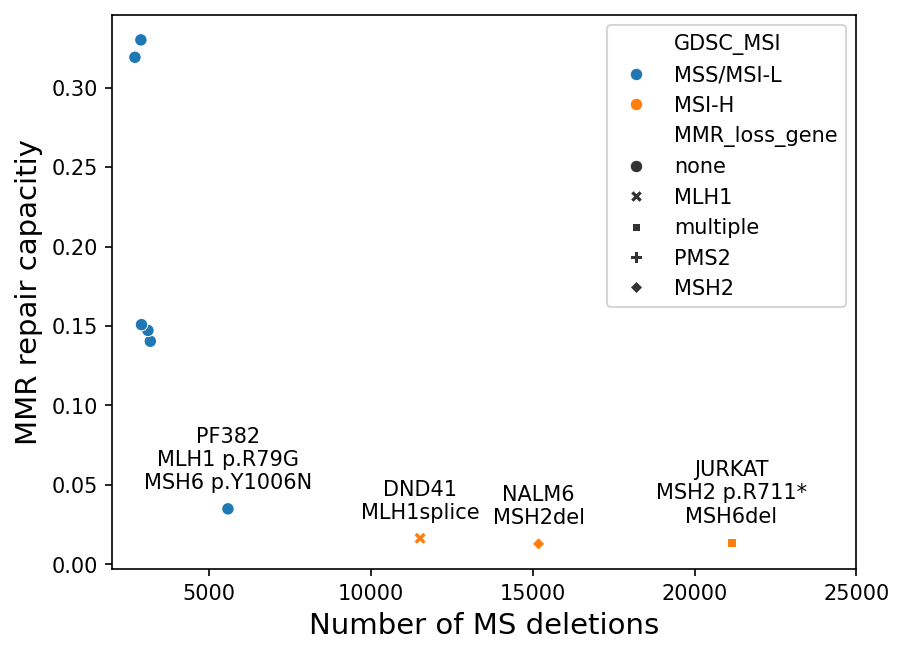

In [15]:
sns.scatterplot(x="ms_deletions_normed",
                y="repair",
                hue="GDSC_MSI",
                style='MMR_loss_gene',
                data=df)
plt.xlabel('Number of MS deletions',fontsize=14)
plt.ylabel('MMR repair capacitiy',fontsize=14)

plt.xlim([2000,25000])

for ind,row in df[df['alteration']!="None"].iterrows():
    plt.text(row["ms_deletions_normed"],
             row["repair"] + .01,
             row['cell_line'] + '\n' + row["alteration"],ha='center',va='bottom')
plt.savefig('pdf/figure5e_scrna_MSI_MMR_comparison.pdf',bbox_inches='tight')

In [16]:
idx = ~df['ms_deletions_normed'].isna()
spearmanr(df.loc[idx,'ms_deletions_normed'],df.loc[idx,'repair'])

SignificanceResult(statistic=np.float64(-0.8549450549450549), pvalue=np.float64(9.766040002967738e-05))

## Figure 5f - U2OS cell cycle

In [17]:
adata = annotate_cell_cycle(adata)

/home/njharlen/anaconda3/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


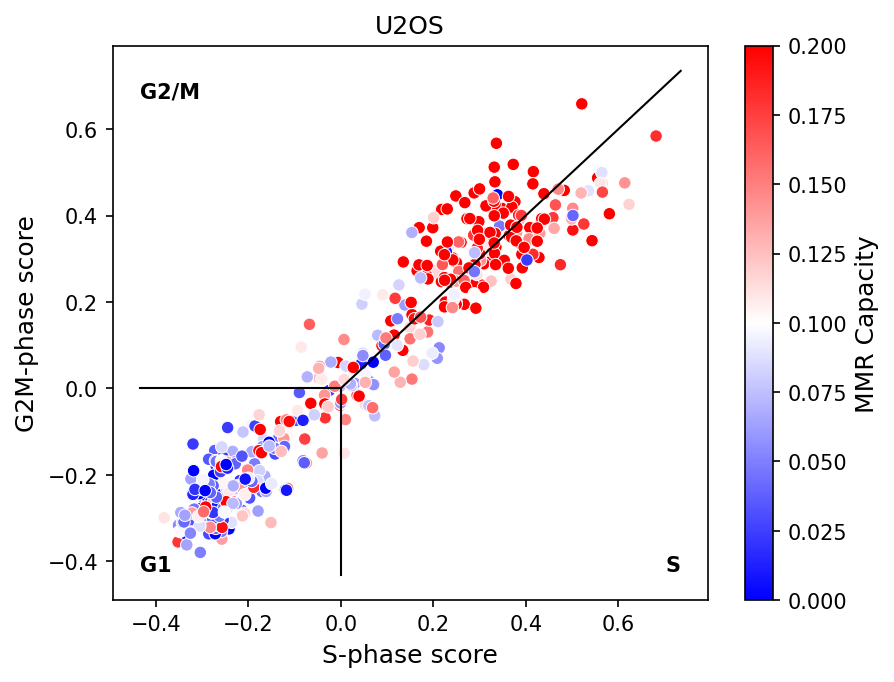

In [57]:
idx = adata.obs['transfected']&(adata.obs['timepoint']=='2h')&(adata.obs['cell_line']=='U2OS')

norm = plt.Normalize(0,.2)
sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm)

sns.scatterplot(x="S_score",y="G2M_score",hue="MMR",data=adata.obs[idx],hue_norm=norm,palette="bwr")

plt.legend().remove()
g=plt.gcf().colorbar(sm,ax=plt.gca())
plt.xlabel('S-phase score',fontsize=12)
plt.ylabel('G2M-phase score',fontsize=12)

g.set_label('MMR Capacity',fontsize=12)


xl = plt.xlim()
yl = plt.ylim()
plt.plot([xl[0],0],[0,0],color='k',linewidth=1)
plt.plot([0,0],[yl[0],0],color='k',linewidth=1)
plt.plot([0,xl[1]],[0,xl[1]],color='k',linewidth=1)

plt.text(xl[0],yl[0],'G1',ha='left',va='bottom',fontweight='bold')
plt.text(xl[1],yl[0],'S',ha='right',va='bottom',fontweight='bold')
plt.text(xl[0],yl[1],'G2/M',ha='left',va='top',fontweight='bold')


plt.title('U2OS')

plt.savefig('pdf/figure5f_U2OS_cell_cycle_correlation.pdf',bbox_inches='tight')

In [19]:
idx1 = idx & (adata.obs['phase']=='G1')
idx2 = idx & (adata.obs['phase'].isin(['S','G2M']))

ranksums(adata.obs.loc[idx1,'MMR'],adata.obs.loc[idx2,'MMR'])

RanksumsResult(statistic=np.float64(-11.73751586920421), pvalue=np.float64(8.185552848587343e-32))

## Figure 5g - MMR cell cycle boxplots

/tmp/ipykernel_403457/1914104437.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = adata.obs[idx].groupby(['cell_line','cycling_subset'])['MMR'].mean().reset_index()
/home/njharlen/anaconda3/lib/python3.10/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):


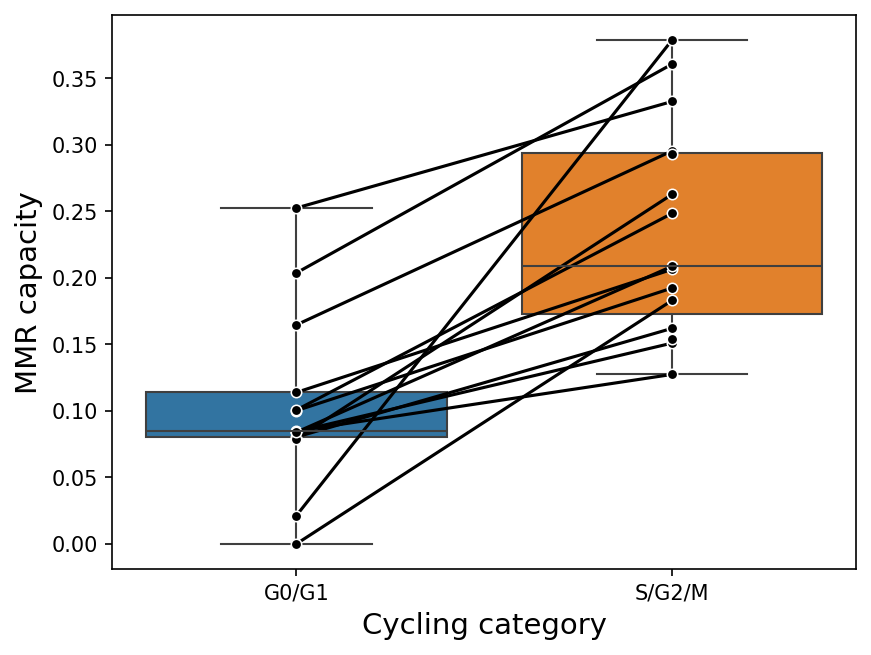

In [20]:
idx = adata.obs['transfected']&(adata.obs['timepoint']=='2h')&(~adata.obs['cell_line'].isin(msi_lines))

adata.obs['cycling_subset'] = adata.obs['phase'].isin(['G2M','S']).map({False : 'G0/G1',True : 'S/G2/M'})


x = adata.obs[idx].groupby(['cell_line','cycling_subset'])['MMR'].mean().reset_index()
sns.boxplot(x="cycling_subset",hue="cycling_subset",y="MMR",data=x,whis=100)
sns.lineplot(x="cycling_subset",y="MMR",units='cell_line',data=x,color='k',estimator=None,marker='o',markersize=5)
plt.ylabel('MMR capacity',fontsize=14)
plt.xlabel('Cycling category',fontsize=14)

plt.savefig('pdf/figure5g_overall_cell_cycle_boxplots.pdf',bbox_inches='tight')

## Figure 5h - BER deletions

/tmp/ipykernel_403457/3851801590.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata[idx].obs.groupby(['label','timepoint','condition'])[['GFP_BAR_007','BER_del']].sum()
/home/njharlen/anaconda3/lib/python3.10/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
/home/njharlen/anaconda3/lib/python3.10/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tru

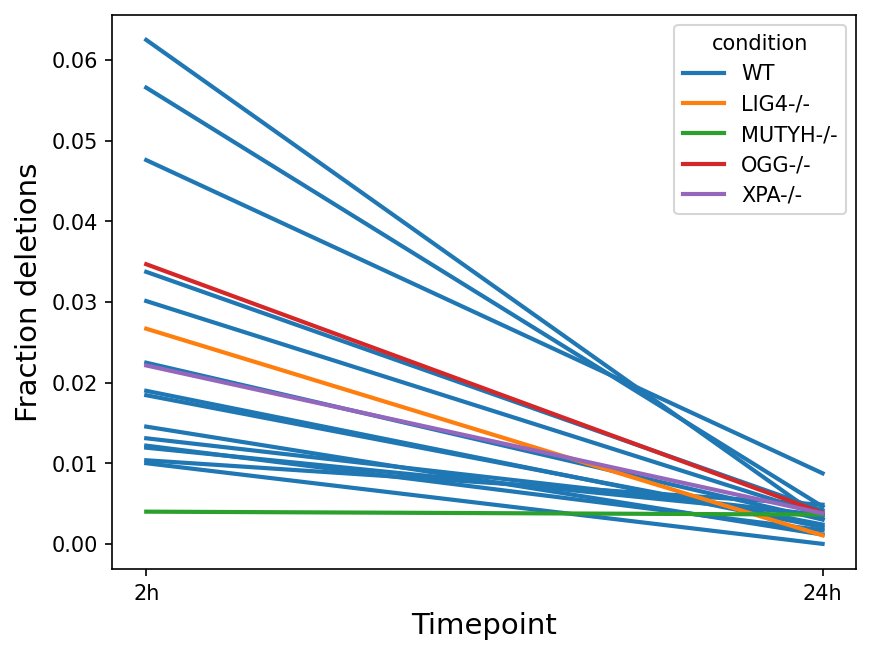

In [21]:
adata.obs['BER_del'] = adata.obsm['del_counts']['GFP_BAR_007']
adata.obs['condition'] = adata.obs['label'].str.split(' ',expand=True)[1].replace({None:'WT'})

adata.obs['condition'] = pd.Categorical(adata.obs['condition'],categories=['WT','LIG4-/-','MUTYH-/-','OGG-/-','XPA-/-'])

idx = adata.obs['transfected']
df = adata[idx].obs.groupby(['label','timepoint','condition'])[['GFP_BAR_007','BER_del']].sum()
df['f_del'] = df['BER_del']/df['GFP_BAR_007']

sns.lineplot(x='timepoint',y='f_del',data=df,hue="condition",linewidth=2,units='label',estimator=None)
plt.ylabel('Fraction deletions',fontsize=14)
plt.xlabel('Timepoint',fontsize=14)

plt.savefig('pdf/figure5h_scrna_ber_deletions.pdf',bbox_inches='tight')

## Accompanying supplementary figure 10

## Supplementary Figure 10A - number of cells per line

Text(0.5, -102.59166666666667, '')

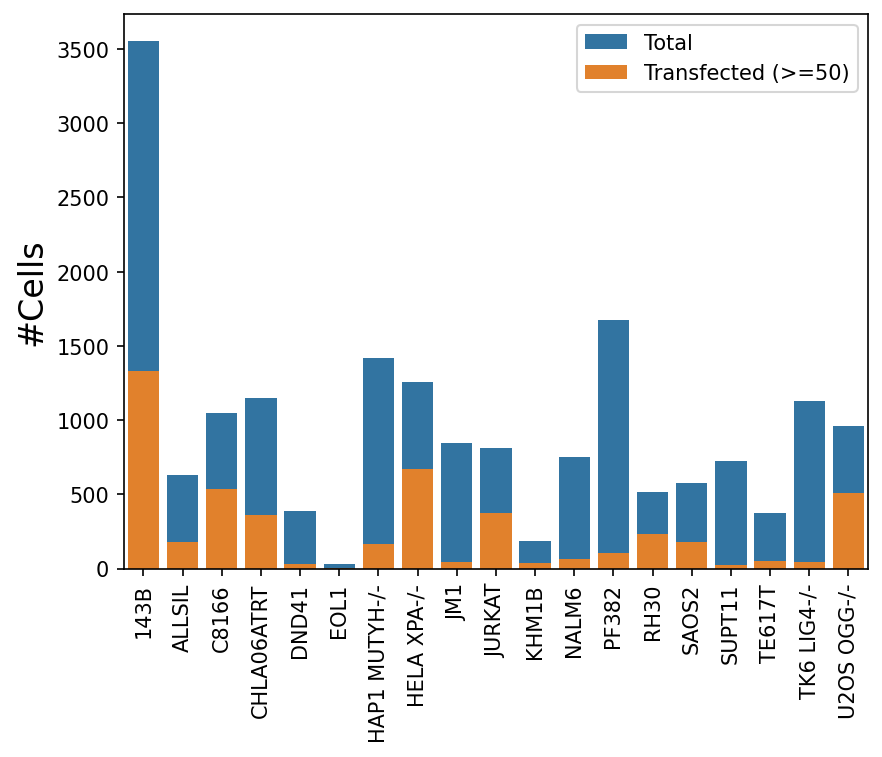

In [22]:
ct1 = adata.obs['label'].value_counts()
ct2 = adata.obs.loc[adata.obs['transfected'],'label'].value_counts()

sns.barplot(x=ct1.index,y=ct1,label='Total')
sns.barplot(x=ct2.index,y=ct2,label='Transfected (>=50)')

plt.xticks(rotation=90);

plt.ylabel('#Cells')

plt.savefig('pdf/supplementary_fig_10a.pdf',bbox_inches='tight')
plt.xlabel('')

## Supplementary Figure 10B - Correlation with bulk expression data

### Download DepMap expression data

In [23]:
from taigapy import create_taiga_client_v3
tc = create_taiga_client_v3()

X_bulk = tc.get("public-25q3-b56c.80/OmicsExpressionTPMLogp1HumanProteinCodingGenes")
X_bulk = X_bulk[X_bulk['IsDefaultEntryForModel']=='Yes']
X_bulk = X_bulk.set_index('ModelID').drop(columns=['SequencingID','IsDefaultEntryForModel','ModelConditionID','IsDefaultEntryForMC'])
X_bulk.columns = X_bulk.columns.str.replace(' .*','',regex=True)

X_bulk = np.expm1(X_bulk)



In [24]:
# Subset to profiled cells and map names
cl_map = adata.uns['cell_line_info']['ModelID'].reset_index().set_index('ModelID')['StrippedCellLineName']

X_bulk = X_bulk.loc[cl_map.index]
X_bulk.index = X_bulk.index.map(cl_map)

### Define marker genes on which to do the comparison

In [25]:
sc.tl.rank_genes_groups(adata,'cell_line')
markers = list()
for l in adata.obs['cell_line'].unique():
    df = sc.get.rank_genes_groups_df(adata,l)
    df = df[df['names'].isin(X_bulk.columns)]
    markers.extend(list(df[df['logfoldchanges']>1].head(n=20)['names'].values))
markers= np.unique(markers)

### Calculate pseudobulk profiles

In [26]:
from ggsc.pseudobulk import calc_pseudobulk_tpm
X_scRNA = calc_pseudobulk_tpm(adata,'cell_line',genes=markers)

Using total_counts for total counts column...


/home/njharlen/git/ggsctools/ggsc/pseudobulk.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ind,g in adata.obs.groupby(groupby)],axis=1).T


In [27]:
Xm_bulk = X_bulk[markers]

In [28]:
from scipy.spatial.distance import cdist, squareform

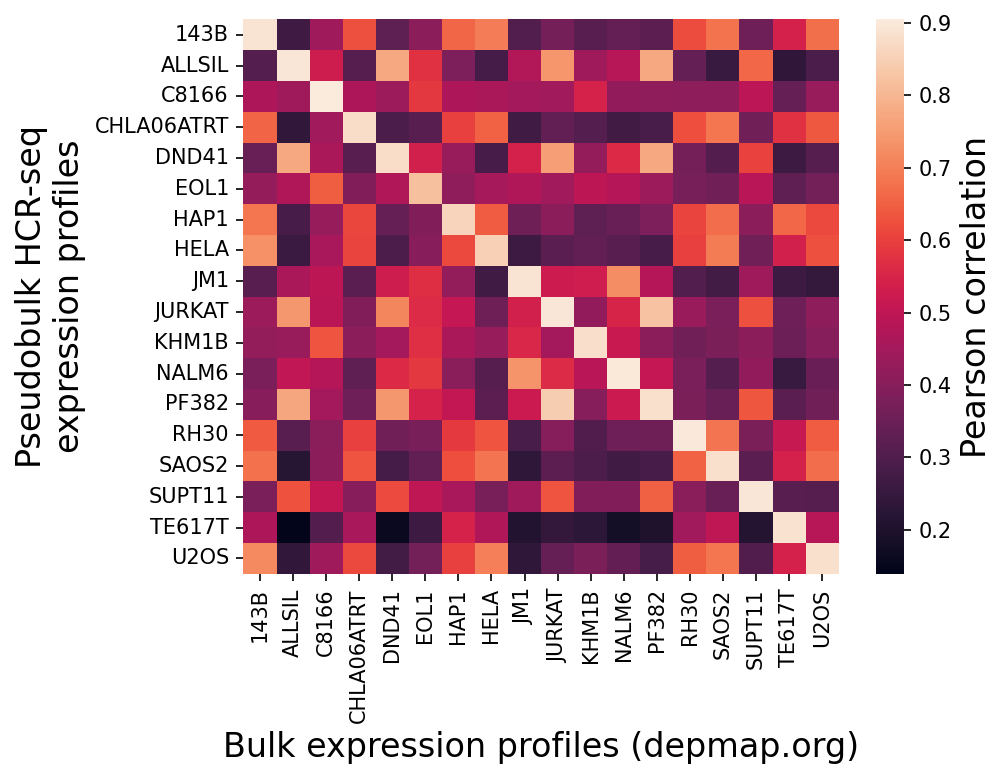

In [29]:
C = pd.DataFrame(cdist(np.log10(1+X_scRNA),np.log10(1+Xm_bulk),metric='correlation'),index = X_scRNA.index,columns=X_bulk.index)


cl_show = C.index[C.index.isin(C.columns)]
sns.heatmap(1-C.loc[cl_show,cl_show],cbar_kws={'label':'Pearson correlation'})
plt.xlabel('Bulk expression profiles (depmap.org)')
plt.ylabel('Pseudobulk HCR-seq\nexpression profiles')

plt.savefig('pdf/supplementary_figure10b_scrna_depmap_expression_correlation.pdf',bbox_inches='tight')


## Supplementary Figure 10c - Fraction cells transfected

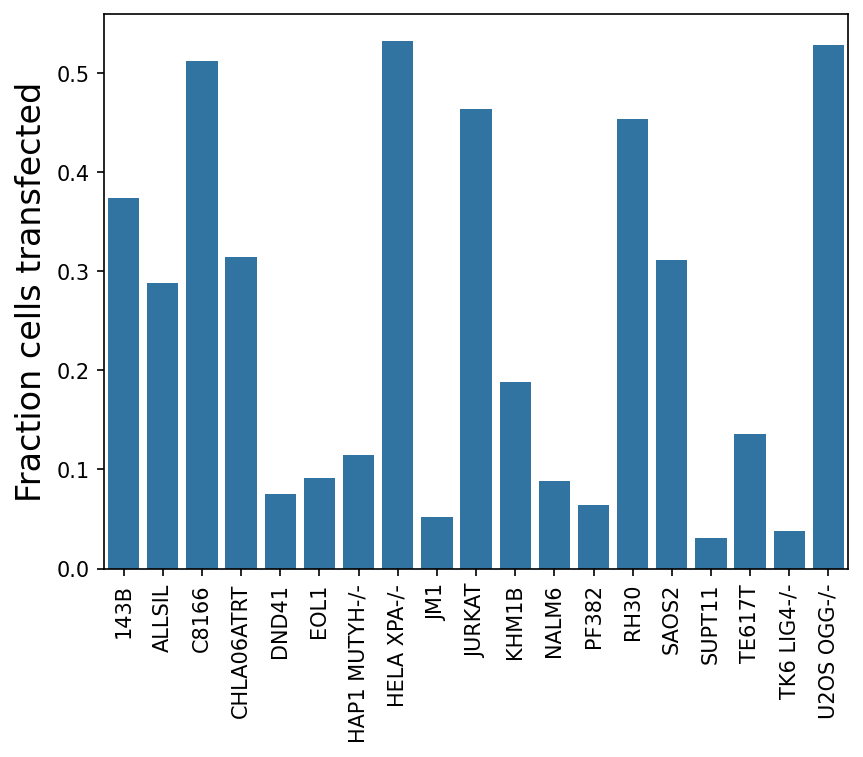

In [30]:
transfection_rate = ct2/ct1
sns.barplot(x=transfection_rate.index,y=transfection_rate)
plt.xticks(rotation=90);

plt.ylabel('Fraction cells transfected')
plt.xlabel('')
plt.savefig('pdf/supplementary_figure10c_scrna_transfection_rate.pdf',bbox_inches='tight')

## Supplementary Figure 10d - UMI counts across reporters

In [31]:
import hcrseq
pathway_info = hcrseq.__path__[0] + '/../reference/HCRseq_v0.3/pathway_calculations.txt'
P = pd.read_csv(pathway_info,sep='\t')

In [32]:
# Merge NHEJ+MMEJ -> DSB
pmap = P.drop_duplicates('reporter').replace({'NHEJ' : 'DSB'}).set_index('reporter')['pathway']

In [33]:
pmap

reporter
GFP_BAR_003               MMR
GFP_BAR_004               NER
GFP_BAR_005          DR_O6MeG
GFP_BAR_006       BER_8oxoG_C
GFP_BAR_007       BER_A_8oxoG
GFP_BAR_008            BER_UG
GFP_BAR_009            BER_Hx
GFP_BAR_DSBR_2            DSB
GFP_BAR_010           control
Name: pathway, dtype: object

In [34]:
adata.obs = adata.obs.rename(columns={'GFP_BAR_DBSR_2' : 'GFP_BAR_DSBR_2'})

/tmp/ipykernel_403457/4240597372.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X = adata.obs[adata.obs['transfected']].groupby('label')[cols].median()


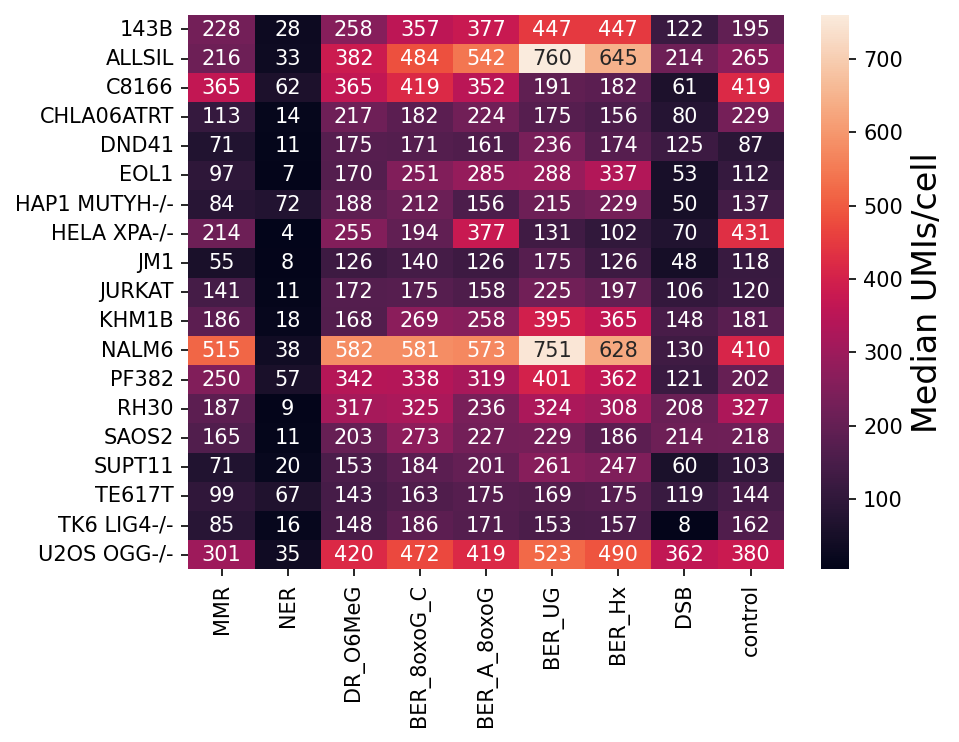

In [35]:
cols = adata.obs.columns[adata.obs.columns.str.match('GFP_BAR')]

X = adata.obs[adata.obs['transfected']].groupby('label')[cols].median()

X = X.rename(columns=pmap)

X = X[list(X.columns[X.columns!='control']) + ['control']]

sns.heatmap(X.astype(int),annot=True,fmt="d",cbar_kws={'label' : 'Median UMIs/cell'})
plt.ylabel('')

plt.savefig('pdf/supplementary_figure10d_scrna_reporter_umi_counts.pdf',bbox_inches='tight')

## Supplementary Figure 10e

/home/njharlen/anaconda3/lib/python3.10/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
/home/njharlen/anaconda3/lib/python3.10/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
/home/njharlen/anaconda3/lib/python3.10/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ad

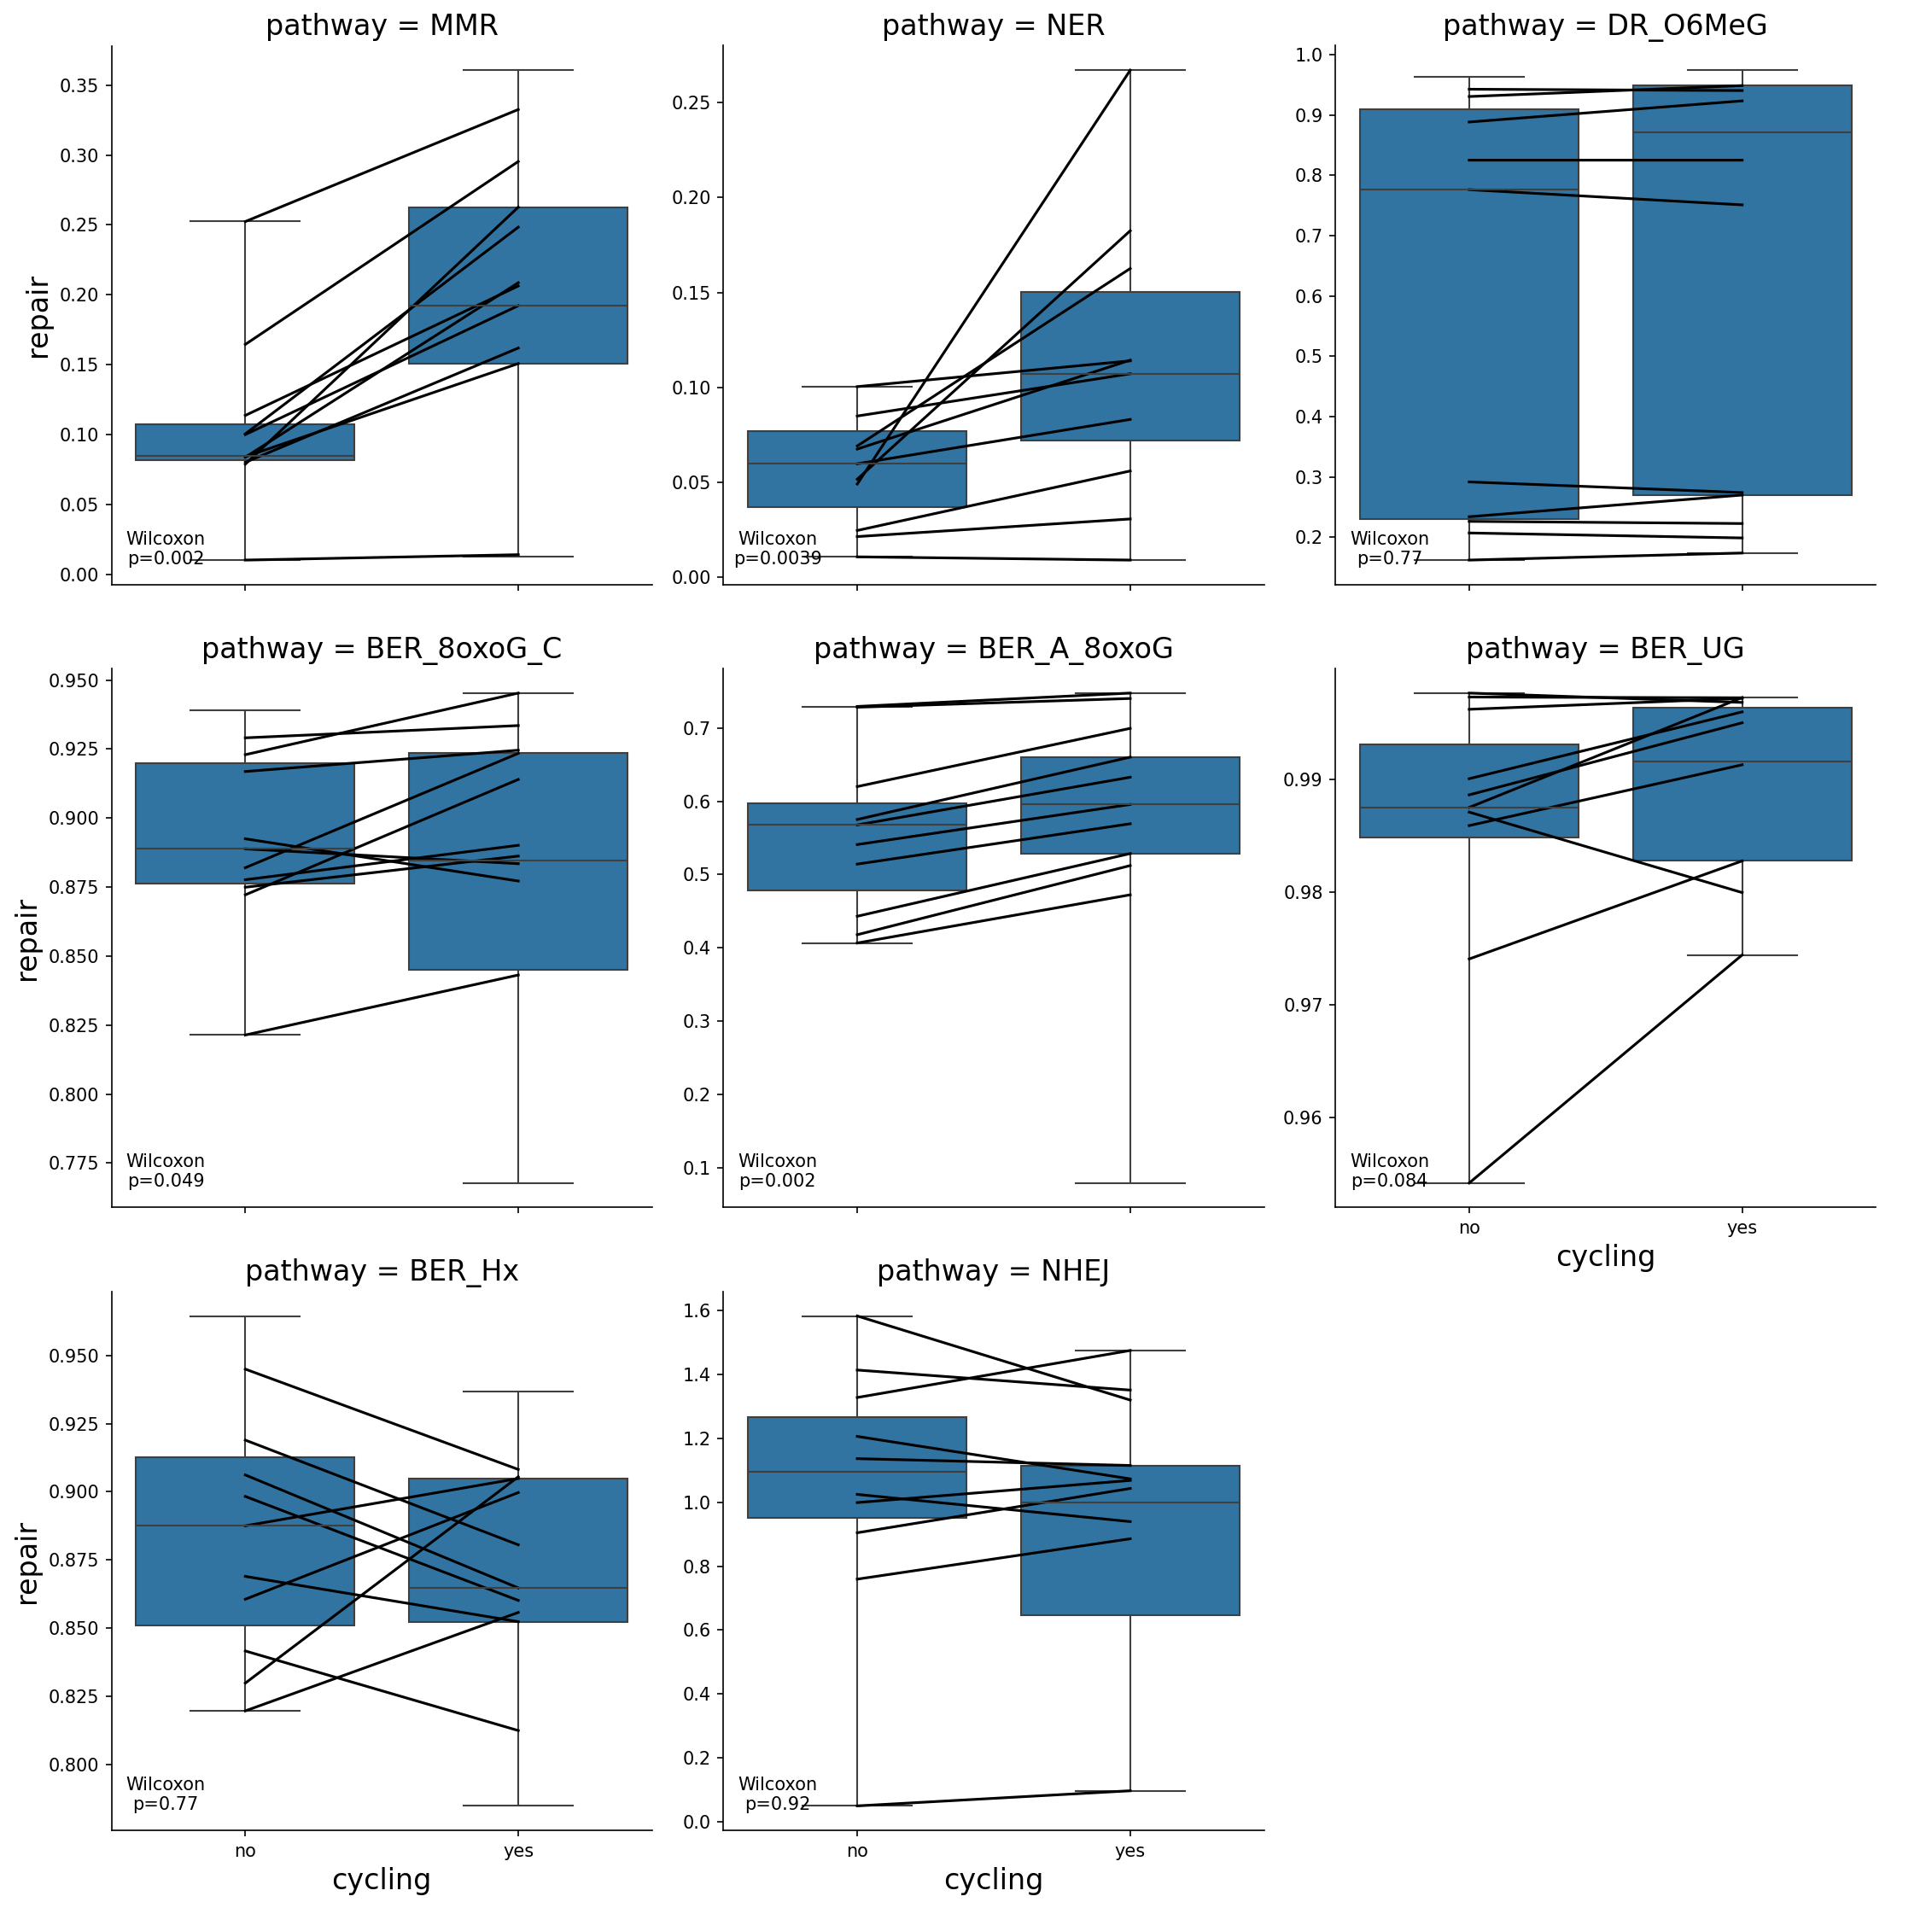

In [36]:

from scipy import stats

def cc_boxplot(adata,pathway,timepoint='2h'):
    idx = adata.obs['transfected']&(adata.obs['timepoint']==timepoint)

    x = get_repair_df(adata[idx],groupby=['cell_line','cycling'])
    x = x[x['n']>=10]

    x = x[x['pathway']==pathway]

    sns.boxplot(x="cycling",hue="cycling",y=pathway,data=x,whis=100)
    sns.lineplot(x="cycling",y="MMR",units='cell_line',data=x,color='k',estimator=None)


def annotate_wilcoxon(data, x, y, units, **kws):
    ax = plt.gca()
    
    # specific to your data: 'cycling' contains the two groups to compare
    groups = data[x].unique()
    
    # We need exactly 2 groups for a Wilcoxon test
    if len(groups) == 2:
        # Pivot data to wide-form to ensure we strictly match pairs by 'cell_line' (units)
        # dropna() ensures we only test complete pairs
        wide_df = data.pivot(index=units, columns=x, values=y).dropna()
        
        # Perform the test if we still have data after matching pairs
        if not wide_df.empty:
            stat, pval = stats.wilcoxon(wide_df[groups[0]], wide_df[groups[1]])
            
            # Annotate plot - adjusting y position (0.95) as needed
            ax.text(0.1, 0.1, f'Wilcoxon\np={pval:.2g}', 
                    transform=ax.transAxes, ha='center', va='top', fontsize=10)


adata.obs['cycling'] = adata.obs['phase'].isin(['G2M','S']).map({True : 'yes',False : 'no'})

idx = adata.obs['transfected']&(adata.obs['timepoint']=='2h')

df = get_repair_df(adata[idx],groupby=['cell_line','cycling'])
df = df[df['n']>=10]

g = sns.catplot(x="cycling",y="repair",col='pathway',data=df,sharey=False,kind='box',col_wrap=3,whis=100)
g.map_dataframe(sns.lineplot,x="cycling",
    y="repair",units="cell_line",estimator=None,color='k')

g.map_dataframe(annotate_wilcoxon, x="cycling", y="repair", units="cell_line")

plt.savefig('pdf/supplementary_figure10e_scrna_cell_cycle_plots.pdf',bbox_inches='tight')
